# **5. SHAP and LIME Analysis**

In [ ]:
# Claude by Anthropic (Opus 4.7) was used as a brainstorming assistant and helping to define the structure
# during the development of this notebook. 
# See AI Disclosure Statement submitted with the thesis for details.

## **5.1 Import libraries and define paths**

In [2]:
from pathlib import Path
import importlib.util
import re
import warnings
import joblib
import numpy as np
import pandas as pd
# xai
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=UserWarning)

target_column = "extreme_precip_99"
lime_num_samples = 5000

current_dir = Path.cwd().resolve()
project_dir = current_dir.parent if current_dir.name == "notebooks" else current_dir

processed_dir = project_dir / "data" / "processed"
results_dir   = project_dir / "results"
models_dir    = results_dir / "models"
xai_dir       = results_dir / "xai"
tables_dir    = xai_dir / "tables"
figures_dir   = xai_dir / "figures"

for folder in [xai_dir, tables_dir, figures_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project directory:    {project_dir}")
print(f"XAI output directory: {xai_dir}")

Project directory:    C:\Users\jensd\Desktop\Data Science\Projects\xai-precipitation-thesis
XAI output directory: C:\Users\jensd\Desktop\Data Science\Projects\xai-precipitation-thesis\results\xai


## **5.2 Load model, data, and selected features**

In [3]:
dataset_path = processed_dir / "era5_supervised_preprocessed.csv"
model_path = models_dir / "xgboost_best_model.joblib"
features_path = results_dir / "xgboost_best_features.csv"
comparison_path = results_dir / "xgboost_model_comparison.csv"
predictions_path = results_dir / "xgboost_best_model_test_predictions.csv"

model = joblib.load(model_path)
df = pd.read_csv(dataset_path, parse_dates=["valid_time"])
features = pd.read_csv(features_path)["feature"].tolist()
model_comparison = pd.read_csv(comparison_path)

best_model_row = model_comparison.iloc[0]
best_feature_set = best_model_row["feature_set"]
best_threshold = float(best_model_row["threshold"])

required_columns = {"valid_time", "split", "tp_mm", target_column, *features}
missing_columns = sorted(required_columns - set(df.columns))
assert not missing_columns, f"dataset missing columns: {missing_columns}"
assert target_column not in features, "target column must not appear as a feature"
assert "tp_mm" not in features, "raw precipitation tp_mm would leak the target"
assert len(features) == len(set(features)), "feature list contains duplicates"

print(f"dataset shape:      {df.shape}")
print(f"time range:         {df['valid_time'].min()} to {df['valid_time'].max()}")
print(f"best feature set:   {best_feature_set} ({len(features)} features)")
print(f"decision threshold: {best_threshold}")

pd.DataFrame({"feature": features}).head(15)

dataset shape:      (131472, 100)
time range:         2010-01-02 00:00:00 to 2024-12-31 23:00:00
best feature set:   selected_history (34 features)
decision threshold: 0.95


,feature
0,t2m_c
1,d2m_c
2,msl_hpa
3,sp_hpa
4,tcc
5,u10
6,v10
7,wind_speed_10m
8,month
9,dayofyear


## **5.3 Prepare train and test explanation data**

In [6]:
train_df = df[df["split"] == "train"].sort_values("valid_time").reset_index(drop=True)
test_df = df[df["split"] == "test"].sort_values("valid_time").reset_index(drop=True)

X_train = train_df[features].astype(float)
X_test = test_df[features].astype(float)
y_test = test_df[target_column].astype(int)

test_probability = model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= best_threshold).astype(int)
test_context = test_df[["valid_time", "tp_mm", target_column]].copy()

assert not X_train.isna().any().any(), "Training do features contain missing values"
assert not X_test.isna().any().any(), "The test features do contain missing values"

print(f"Train: {len(X_train):,} samples  ({int(train_df[target_column].sum())} extremes)")
print(f"Test:  {len(X_test):,} samples  ({int(y_test.sum())} extremes, {int(test_prediction.sum())} predicted)")

Train: 105,177 samples  (966 extremes)
Test:  26,295 samples  (349 extremes, 381 predicted)


## **5.4 Validate model predictions**

In [7]:
saved_predictions = pd.read_csv(predictions_path, parse_dates=["valid_time"])

assert len(saved_predictions) == len(X_test), ("Saved predictions don't match test set size")
assert saved_predictions["valid_time"].equals(test_df["valid_time"]), ("Saved prediction timestamps don't match test set")
assert np.allclose(test_probability, saved_predictions["predicted_probability"], atol=1e-6), ("Loaded model predictions don't match notebook 04 (wrong)")

print(f"Correct loded model reproduces {len(saved_predictions):,} test predictions from notebook 04")

Correct loded model reproduces 26,295 test predictions from notebook 04


## **5.5 Global SHAP analysis**

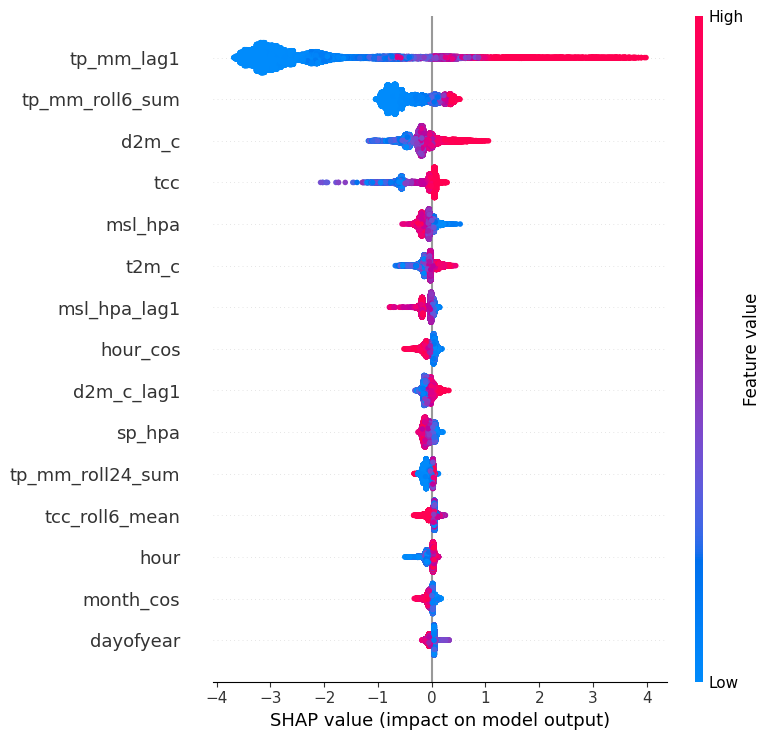

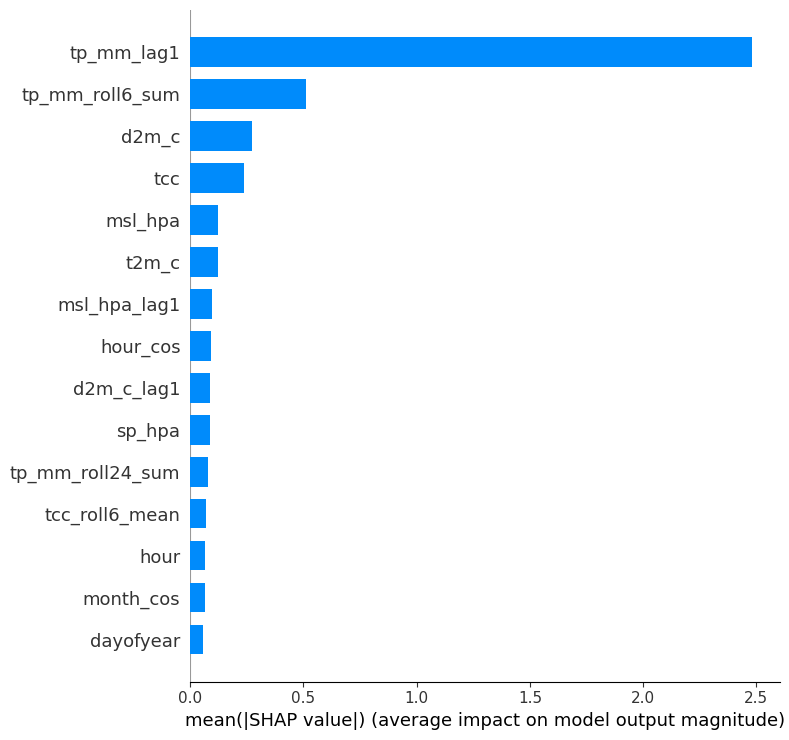

,feature,mean_abs_shap,mean_shap
0,tp_mm_lag1,2.480255,-2.211066
1,tp_mm_roll6_sum,0.512403,-0.418387
2,d2m_c,0.274074,-0.163210
3,tcc,0.235505,-0.196247
4,msl_hpa,0.121761,-0.086044
5,t2m_c,0.121359,-0.062687
6,msl_hpa_lag1,0.094861,-0.073740
7,hour_cos,0.090510,-0.042257
8,d2m_c_lag1,0.089089,-0.052323
9,sp_hpa,0.087953,-0.058512


In [8]:
# AI for guidance on how to code this the best (no experience)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values = shap_values[1]
shap_values = np.asarray(shap_values)
assert shap_values.shape == X_test.shape

global_shap = (
    pd.DataFrame(
        {
            "feature": features,
            "mean_abs_shap": np.abs(shap_values).mean(axis=0),
            "mean_shap": shap_values.mean(axis=0),
        }
    )
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

global_shap.to_csv(tables_dir / "shap_global_importance.csv", index=False)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.tight_layout()
plt.savefig(figures_dir / "shap_summary_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15, show=False)
plt.tight_layout()
plt.savefig(figures_dir / "shap_summary_bar.png", dpi=200, bbox_inches="tight")
plt.show()

global_shap.head(15)

## **5.6 Local SHAP Explanations**

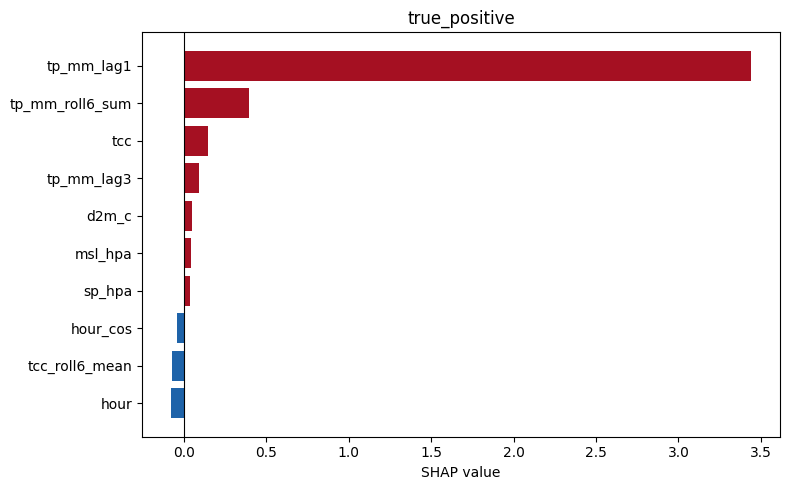

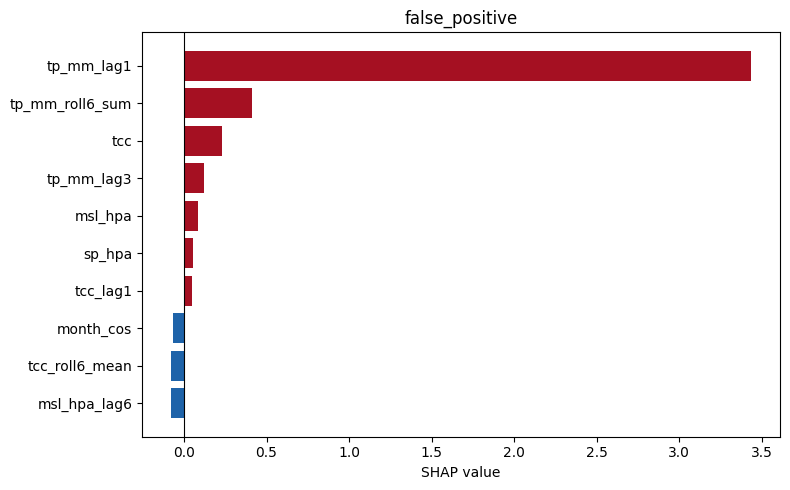

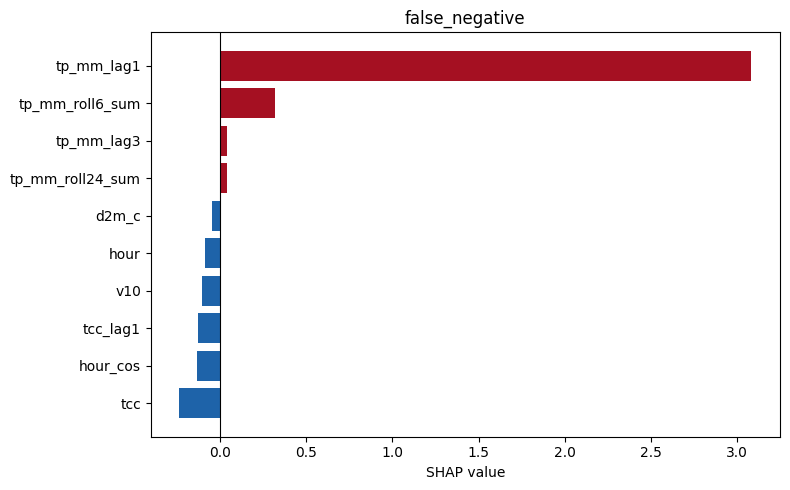

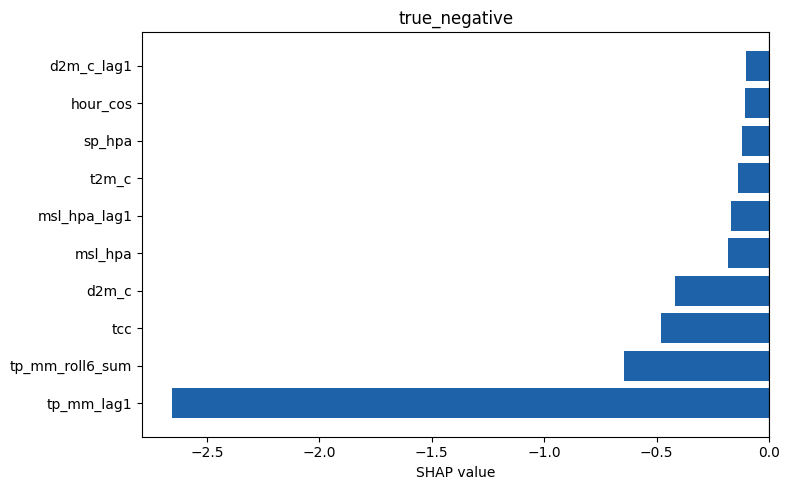

,case,valid_time,tp_mm,extreme_precip_99,predicted_probability,predicted_class
13724,true_positive,2023-07-27 05:00:00,3.120422,1,0.985655,1
15770,false_positive,2023-10-20 11:00:00,1.534462,0,0.985366,1
4047,false_negative,2022-06-19 00:00:00,3.060818,1,0.949916,0
8413,true_negative,2022-12-17 22:00:00,0.000000,0,0.004186,0


In [9]:
predictions = test_context.copy()
predictions["predicted_probability"] = test_probability
predictions["predicted_class"] = test_prediction

tp_mask = (predictions[target_column] == 1) & (predictions["predicted_class"] == 1)
fp_mask = (predictions[target_column] == 0) & (predictions["predicted_class"] == 1)
fn_mask = (predictions[target_column] == 1) & (predictions["predicted_class"] == 0)
tn_mask = (predictions[target_column] == 0) & (predictions["predicted_class"] == 0)

case_rows = [
    predictions.loc[tp_mask, "predicted_probability"].idxmax(),
    predictions.loc[fp_mask, "predicted_probability"].idxmax(),
    predictions.loc[fn_mask, "predicted_probability"].idxmax(),
    predictions.loc[tn_mask, "predicted_probability"].idxmin(),
]
case_names = ["true_positive", "false_positive", "false_negative", "true_negative"]

selected_cases = predictions.loc[case_rows].copy()
selected_cases.insert(0, "case", case_names)
selected_cases.to_csv(tables_dir / "local_explanation_cases.csv", index=False)

case_shap_values = explainer.shap_values(X_test.iloc[case_rows])
if isinstance(case_shap_values, list):
    case_shap_values = case_shap_values[1]
case_shap_values = np.asarray(case_shap_values)

local_shap_tables = []
for i, (row_id, case_name) in enumerate(zip(case_rows, case_names)):
    case_table = pd.DataFrame(
        {
            "case": case_name,
            "feature": features,
            "feature_value": X_test.iloc[row_id].to_numpy(),
            "shap_value": case_shap_values[i],
        }
    )
    case_table["abs_shap"] = case_table["shap_value"].abs()
    local_shap_tables.append(case_table)

    top = case_table.nlargest(10, "abs_shap").sort_values("shap_value")
    colors = np.where(top["shap_value"] >= 0, "#a51022", "#1e63a9")

    plt.figure(figsize=(8, 5))
    plt.barh(top["feature"], top["shap_value"], color=colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(case_name)
    plt.xlabel("SHAP value")
    plt.tight_layout()
    plt.savefig(
        figures_dir / f"shap_local_{case_name}.png", dpi=200, bbox_inches="tight"
    )
    plt.show()

local_shap = pd.concat(local_shap_tables, ignore_index=True)
local_shap.to_csv(tables_dir / "shap_local_explanations.csv", index=False)

selected_cases

## **5.7 Prepare LIME explainer**

In [10]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train.to_numpy(),
    feature_names=features,
    class_names=["non_extreme", "extreme"],
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)


def predict_for_lime(rows):
    return model.predict_proba(pd.DataFrame(rows, columns=features))

## **5.8 Local LIME explanations**

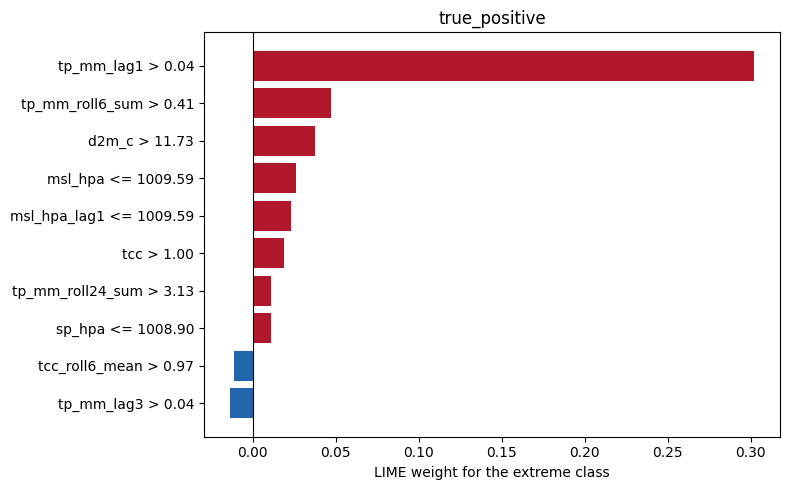

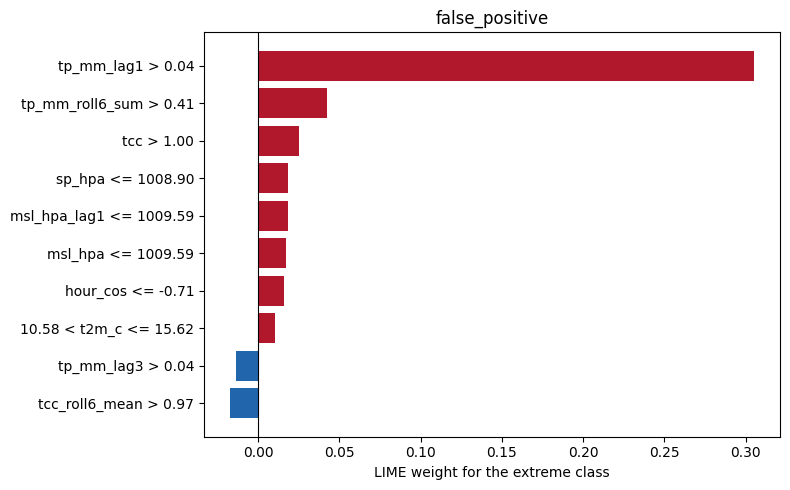

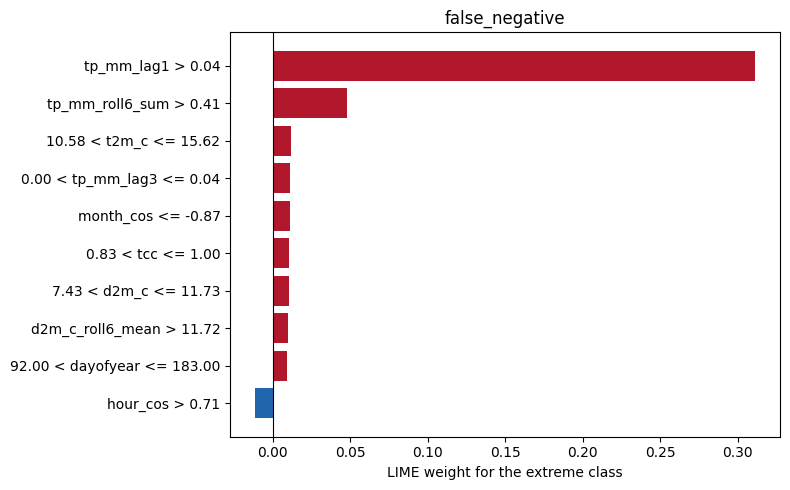

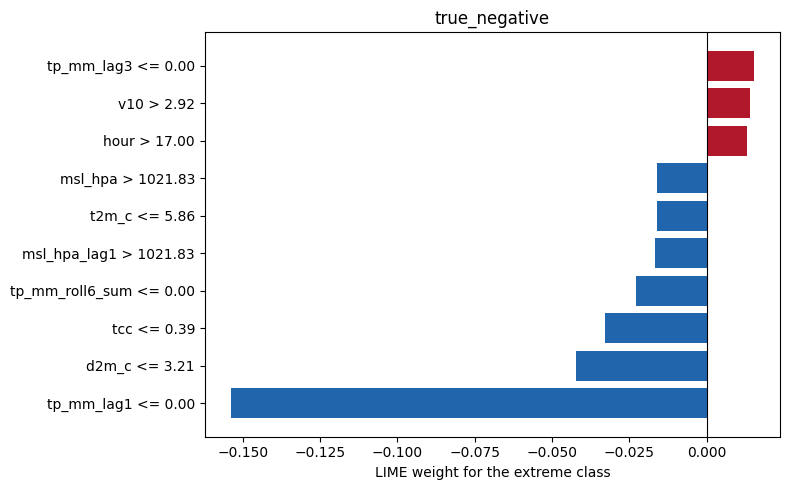

,lime_rule,lime_weight,case,abs_lime_weight
0,tp_mm_lag1 > 0.04,0.301755,true_positive,0.301755
1,tp_mm_roll6_sum > 0.41,0.046882,true_positive,0.046882
2,d2m_c > 11.73,0.037456,true_positive,0.037456
3,msl_hpa <= 1009.59,0.025836,true_positive,0.025836
4,msl_hpa_lag1 <= 1009.59,0.023090,true_positive,0.023090
5,tcc > 1.00,0.018594,true_positive,0.018594
6,tp_mm_lag3 > 0.04,-0.013673,true_positive,0.013673
7,tcc_roll6_mean > 0.97,-0.011509,true_positive,0.011509
8,tp_mm_roll24_sum > 3.13,0.011007,true_positive,0.011007
9,sp_hpa <= 1008.90,0.010684,true_positive,0.010684


In [12]:
lime_tables = []

for row_id, case in selected_cases.iterrows():
    case_name = case["case"]

    lime_explanation = lime_explainer.explain_instance(
        data_row=X_test.iloc[row_id].to_numpy(),
        predict_fn=predict_for_lime,
        labels=[1],
        num_features=10,
        num_samples=5000,
    )

    case_lime = pd.DataFrame(
        lime_explanation.as_list(label=1), columns=["lime_rule", "lime_weight"]
    )
    case_lime["case"] = case_name
    case_lime["abs_lime_weight"] = case_lime["lime_weight"].abs()
    lime_tables.append(case_lime)

    plot_data = case_lime.sort_values("lime_weight")
    colors = np.where(plot_data["lime_weight"] >= 0, "#b2182b", "#2166ac")

    plt.figure(figsize=(8, 5))
    plt.barh(plot_data["lime_rule"], plot_data["lime_weight"], color=colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(case_name)
    plt.xlabel("LIME weight for the extreme class")
    plt.tight_layout()
    plt.savefig(
        figures_dir / f"lime_local_{case_name}.png", dpi=200, bbox_inches="tight"
    )
    plt.show()

lime_results = pd.concat(lime_tables, ignore_index=True)
lime_results.to_csv(tables_dir / "lime_local_explanations.csv", index=False)

lime_results

## **5.9 Compare SHAP and LIME explanations**

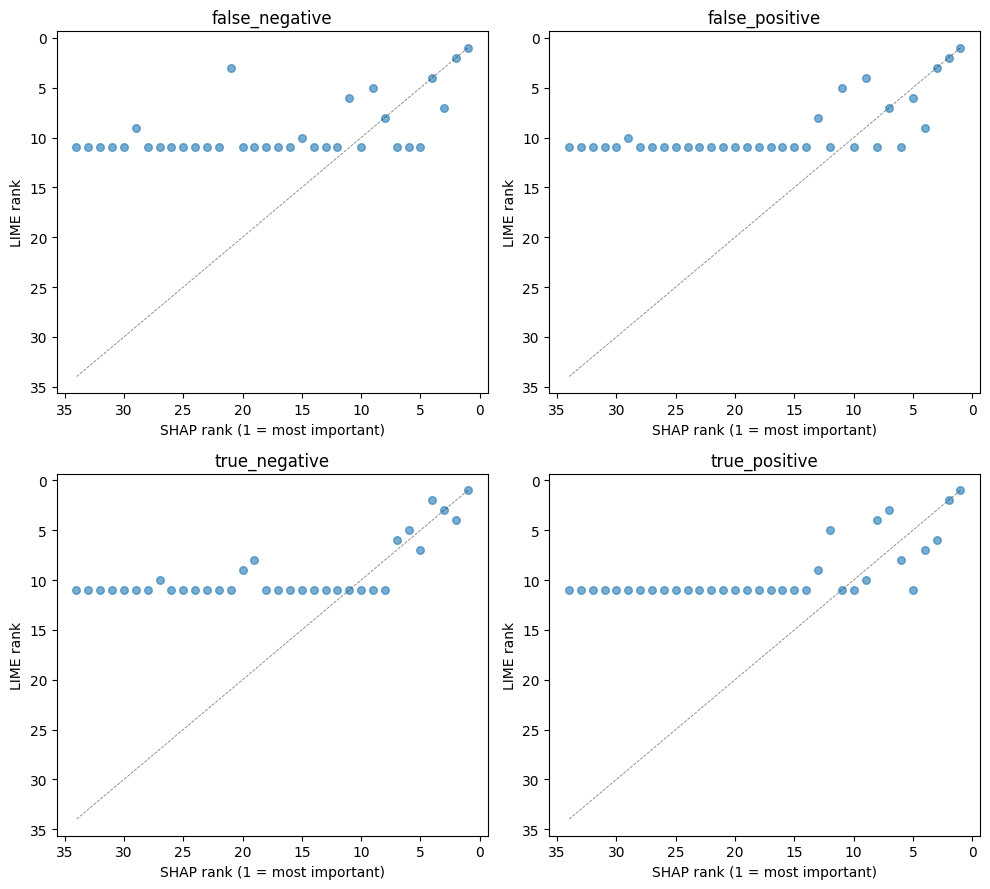

,case,top10_overlap,spearman_rho
0,false_negative,6,0.511667
1,false_positive,7,0.644658
2,true_negative,7,0.605197
3,true_positive,8,0.732877


In [14]:
features_by_length = sorted(features, key=len, reverse=True)


def extract_feature_from_rule(rule):
    for feature in features_by_length:
        if feature in rule:
            return feature
    return None


lime_per_case = lime_results.copy()
lime_per_case["feature"] = lime_per_case["lime_rule"].apply(extract_feature_from_rule)
lime_per_case = lime_per_case.groupby(["case", "feature"], as_index=False)[
    "abs_lime_weight"
].sum()

comparison = (
    local_shap[["case", "feature", "abs_shap"]]
    .merge(lime_per_case, on=["case", "feature"], how="outer")
    .fillna(0)
)
comparison.to_csv(tables_dir / "shap_lime_comparison.csv", index=False)

agreement_rows = []
for case_name, sub in comparison.groupby("case"):
    top10_shap = set(sub.nlargest(10, "abs_shap")["feature"])
    top10_lime = set(sub.nlargest(10, "abs_lime_weight")["feature"])
    agreement_rows.append(
        {
            "case": case_name,
            "top10_overlap": len(top10_shap & top10_lime),
            "spearman_rho": sub["abs_shap"].corr(
                sub["abs_lime_weight"], method="spearman"
            ),
        }
    )
agreement = pd.DataFrame(agreement_rows)
agreement.to_csv(tables_dir / "shap_lime_agreement.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (case_name, sub) in zip(axes.flat, comparison.groupby("case")):
    sub = sub.copy()
    sub["shap_rank"] = sub["abs_shap"].rank(ascending=False, method="min")
    sub["lime_rank"] = sub["abs_lime_weight"].rank(ascending=False, method="min")
    ax.scatter(sub["shap_rank"], sub["lime_rank"], alpha=0.6, s=30)
    n = len(sub)
    ax.plot([1, n], [1, n], "k--", linewidth=0.6, alpha=0.5)
    ax.set_xlabel("SHAP rank (1 = most important)")
    ax.set_ylabel("LIME rank")
    ax.set_title(case_name)
    ax.invert_xaxis()
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig(figures_dir / "shap_lime_rank_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

agreement